# ResNet - CT Scan Lung Disease Classification

**Classes:** ACA | LCC | NORM | SCC

Dataset path: `dataset/ct-scan/{aca, lcc, norm, scc}`


## 1. Install & Import Dependencies


In [ ]:
# Uncomment if packages not installed
!pip install torch torchvision timm scikit-learn matplotlib seaborn tqdm

import os
import copy
from typing import Literal
from os.path import join
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


## 2. Configuration


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
path = ".."
output = ".."
kaggle = False

if kaggle:
    path = "/kaggle/input/datasets/ebadansari/dataset"
    output = join("kaggle", "working")

dataset: Literal["ct-scan", "pathalogy"] = "pathalogy"
DATA_DIR   = Path(join(path, 'dataset', dataset))   # adjust if needed
SAVE_DIR   = Path(join(output, 'outputs/resnet'))
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR         = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE   = 7          # early stopping patience

# Train / Val / Test split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['aca', 'lcc', 'norm', 'scc']
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

Classes: ['aca', 'lcc', 'norm', 'scc']


## 3. Data Transforms & Dataset


In [13]:
# ImageNet mean/std for pretrained ResNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(DATA_DIR)
print(f'Total images : {len(full_dataset)}')
print(f'Class map    : {full_dataset.class_to_idx}')

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_split, val_split, test_split = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Custom Subset class to handle transforms correctly
class SubsetWithTransform(torch.utils.data.Subset):
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self._transform = transform
        
    def __getitem__(self, idx):
        # Access original image path from the ImageFolder dataset
        img_path, label = self.dataset.imgs[self.indices[idx]]
        from PIL import Image
        img = Image.open(img_path).convert('RGB')
        if self._transform:
            img = self._transform(img)
        return img, label

    # Required for PyTorch Subset subclasses to work with DataLoader
    def __getitems__(self, indices):
        return [self.__getitem__(idx) for idx in indices]
# Updated with num_workers=0 to prevent Windows multiprocessing crashes
train_loader = DataLoader(
    SubsetWithTransform(full_dataset, train_split.indices, train_tf), 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,  # Change from 2 to 0
    pin_memory=True
)

val_loader = DataLoader(
    SubsetWithTransform(full_dataset, val_split.indices, eval_tf),
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,  # Change from 2 to 0
    pin_memory=True
)

test_loader = DataLoader(
    SubsetWithTransform(full_dataset, test_split.indices, eval_tf),
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,  # Change from 2 to 0
    pin_memory=True
)


print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Total images : 864
Class map    : {'aca': 0, 'lcc': 1, 'norm': 2, 'scc': 3}
Train: 604 | Val: 129 | Test: 131


## 4. Visualise Sample Images


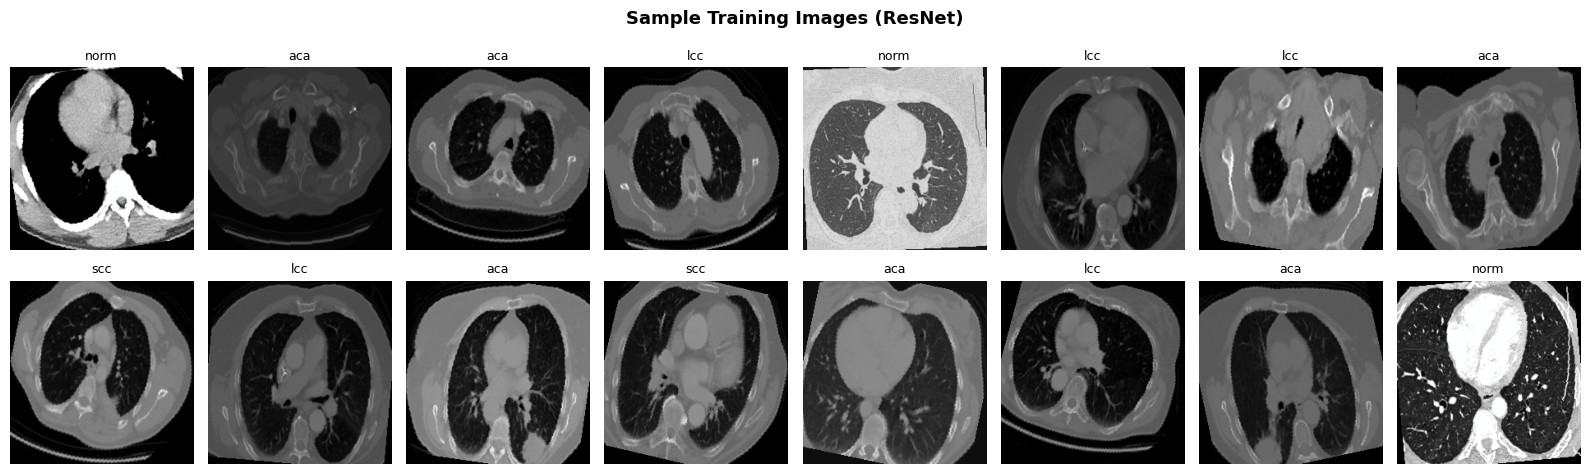

In [14]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(np.array(STD) * inp + np.array(MEAN), 0, 1)
    plt.imshow(inp)
    if title: plt.title(title, fontsize=9)
    plt.axis('off')

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(imgs[i], CLASS_NAMES[labels[i]])
plt.suptitle('Sample Training Images (ResNet)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'sample_images.png', dpi=150)
plt.show()

## 5. Build ResNet-50 Model (Transfer Learning)


In [15]:
def build_resnet(num_classes=4, freeze_backbone=False):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Replace classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_resnet(NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


Total params     : 24,033,604
Trainable params : 24,033,604


## 6. Loss, Optimiser & Scheduler


In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Criterion  :', criterion)
print('Optimizer  :', optimizer.__class__.__name__)
print('Scheduler  :', scheduler.__class__.__name__)

Criterion  : CrossEntropyLoss()
Optimizer  : AdamW
Scheduler  : CosineAnnealingLR


## 7. Training Loop


In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc  = 0.0
best_weights  = None
patience_cnt  = 0

print(f'Training ResNet-50 for {NUM_EPOCHS} epochs ...\n')
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    flag = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_DIR / 'resnet50_best.pth')
        patience_cnt = 0
        flag = '  ✓ saved'
    else:
        patience_cnt += 1

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {t_loss:.4f}  Acc: {t_acc*100:.2f}%  |  '
          f'Val Loss: {v_loss:.4f}  Acc: {v_acc*100:.2f}%  '
          f'LR: {lr_now:.2e}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).')
        break

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed/60:.1f} min  |  Best Val Acc: {best_val_acc*100:.2f}%')
model.load_state_dict(best_weights)

Training ResNet-50 for 30 epochs ...



Epoch [01/30]  Train Loss: 1.3290  Acc: 33.77%  |  Val Loss: 1.3242  Acc: 37.21%  LR: 9.97e-05  ✓ saved


Epoch [02/30]  Train Loss: 1.1932  Acc: 45.86%  |  Val Loss: 1.2660  Acc: 40.31%  LR: 9.89e-05  ✓ saved


Epoch [03/30]  Train Loss: 1.1067  Acc: 56.46%  |  Val Loss: 1.1614  Acc: 55.04%  LR: 9.76e-05  ✓ saved


Epoch [04/30]  Train Loss: 0.9523  Acc: 67.38%  |  Val Loss: 1.0270  Acc: 55.81%  LR: 9.57e-05  ✓ saved


...

Epoch [26/30]  Train Loss: 0.3776  Acc: 99.83%  |  Val Loss: 0.5016  Acc: 93.80%  LR: 5.28e-06


Epoch [27/30]  Train Loss: 0.3736  Acc: 99.83%  |  Val Loss: 0.5043  Acc: 93.80%  LR: 3.42e-06


Epoch [28/30]  Train Loss: 0.3833  Acc: 99.17%  |  Val Loss: 0.5026  Acc: 94.57%  LR: 2.08e-06


Epoch [29/30]  Train Loss: 0.3809  Acc: 99.34%  |  Val Loss: 0.4992  Acc: 94.57%  LR: 1.27e-06

Early stopping at epoch 29 (no val improvement for 7 epochs).

Training complete in 6.1 min  |  Best Val Acc: 94.57%


<All keys matched successfully>

## 8. Training Curves


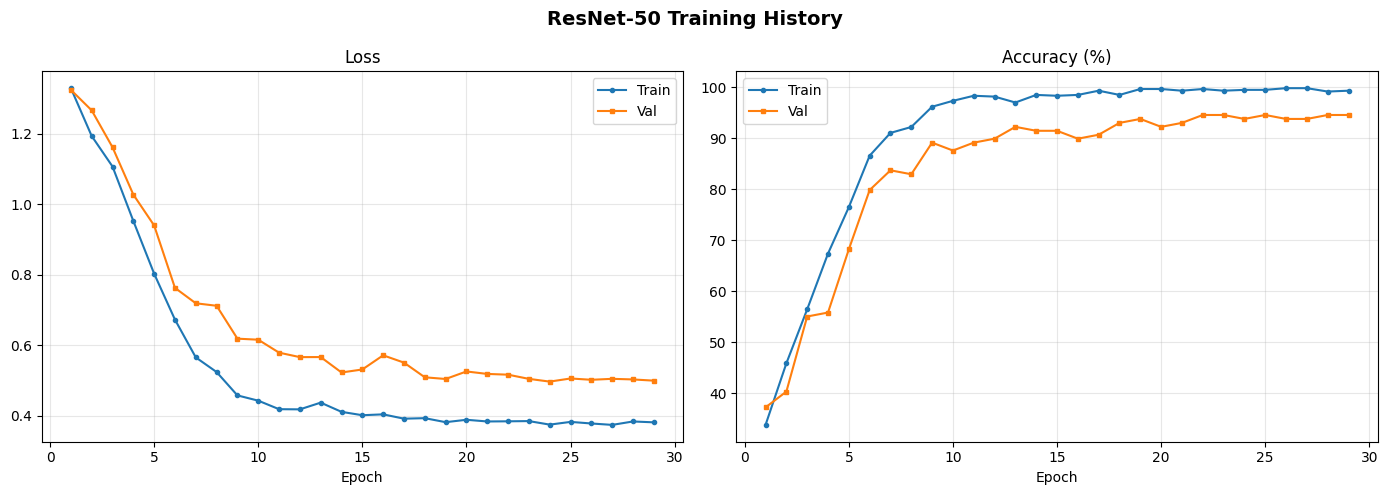

In [18]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o', markersize=3)
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='s', markersize=3)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train', marker='o', markersize=3)
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val',   marker='s', markersize=3)
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-50 Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()

## 9. Evaluate on Test Set


In [19]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader)
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc*100:.2f}%')

Test Loss : 0.5173
Test Acc  : 91.60%


## 10. Classification Report & Confusion Matrix



Classification Report:
              precision    recall  f1-score   support

         aca       0.87      0.94      0.90        48
         lcc       0.91      0.91      0.91        23
        norm       0.96      0.96      0.96        28
         scc       0.96      0.84      0.90        32

    accuracy                           0.92       131
   macro avg       0.93      0.91      0.92       131
weighted avg       0.92      0.92      0.92       131



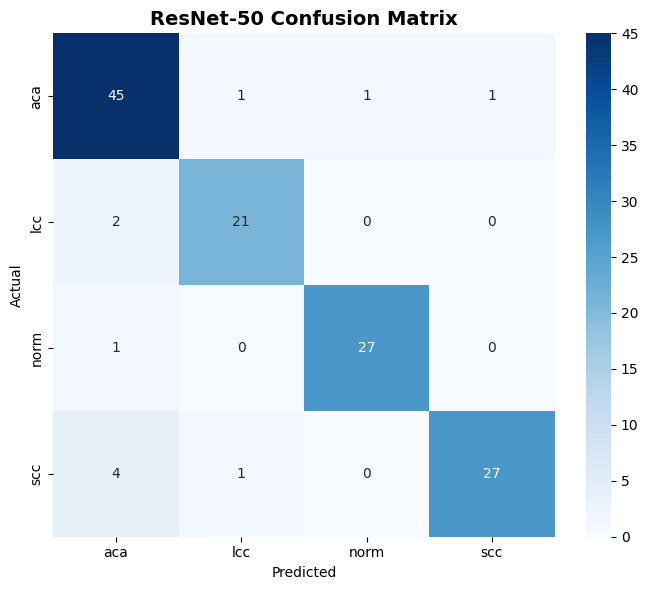

In [20]:
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('ResNet-50 Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 11. Save Final Model


In [21]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'test_accuracy'    : test_acc,
    'history'          : history,
}, SAVE_DIR / 'resnet50_final.pth')

print(f'Model saved to {SAVE_DIR / "resnet50_final.pth"}')
print(f'Best Val Acc : {best_val_acc*100:.2f}%')
print(f'Test Acc     : {test_acc*100:.2f}%')

Model saved to /kaggle/working/outputs/resnet/resnet50_final.pth
Best Val Acc : 94.57%
Test Acc     : 91.60%
